# 🚢 Titanic Data Analyst Capstone Project
A complete step-by-step Data Analysis project using Python, NumPy, Pandas, and Matplotlib with detailed explanations.

## Step 1: Import Required Libraries
**Explanation:** We need `numpy` for numerical operations, `pandas` for data manipulation, and `matplotlib.pyplot` for plotting charts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Load the Dataset
**Explanation:** Load the CSV file into a DataFrame and display the first few rows to understand its structure.

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Understand the Dataset Structure
**Explanation:** Check dataset dimensions, column types, and summary statistics to understand the data better.

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 4: Check Missing Values
**Explanation:** Identify columns with missing data to handle them in cleaning step.

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 5: Data Cleaning
**Explanation:** Handle missing values and create new features.

In [5]:
# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin feature engineering
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df = df.drop(columns=['Cabin'])
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

## Step 6: Basic Survival Analysis
**Explanation:** Understand the overall survival distribution in percentage and count.

In [6]:
df['Survived'].value_counts()
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

## Step 7: Survival by Gender
**Explanation:** Compare survival rate between males and females.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


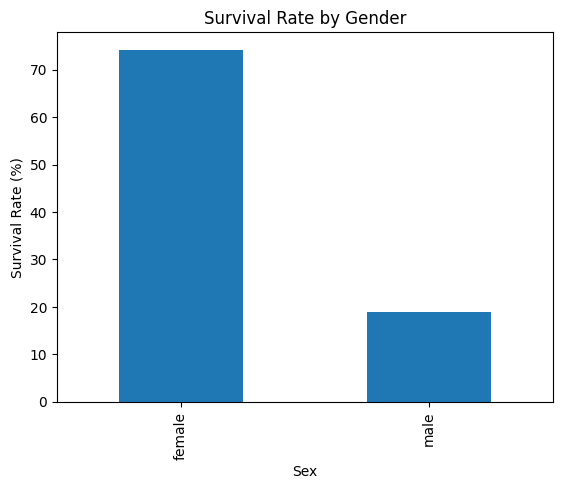

In [7]:
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100
print(survival_by_gender)

survival_by_gender.plot(kind='bar')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (%)')
plt.show()

## Step 8: Survival by Passenger Class
**Explanation:** Analyze if passenger class impacted survival chances.

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


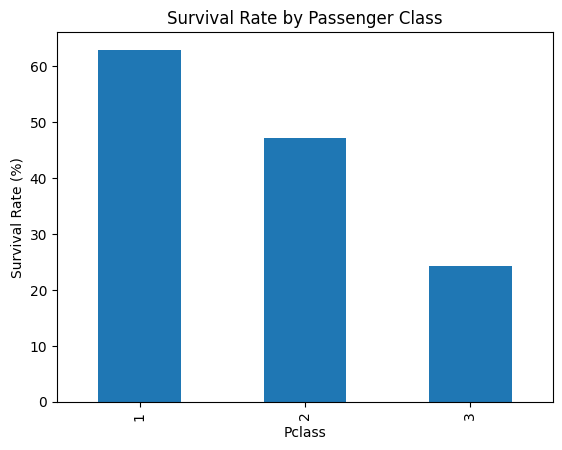

In [8]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
print(survival_by_class)

survival_by_class.plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.show()

## Step 9: Age Group Analysis
**Explanation:** Categorize ages into groups to see how age affects survival.

AgeGroup
Child     57.971014
Teen      38.181818
Adult     36.476868
Senior    39.062500
Elder     22.727273
Name: Survived, dtype: float64


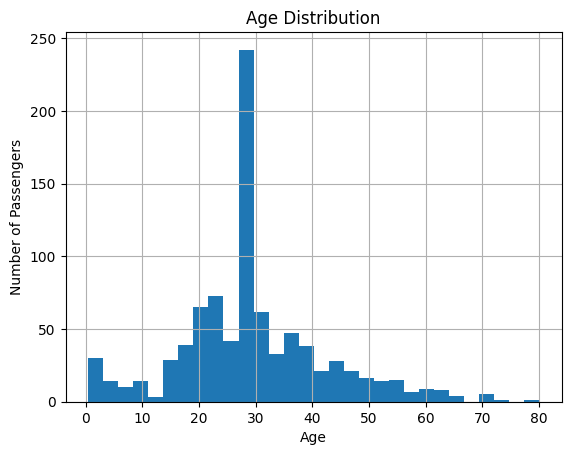

In [9]:
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior', 'Elder']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

survival_by_agegroup = df.groupby('AgeGroup')['Survived'].mean() * 100
print(survival_by_agegroup)

df['Age'].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## Step 10: Fare Analysis
**Explanation:** Analyze the impact of ticket fare on survival.

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


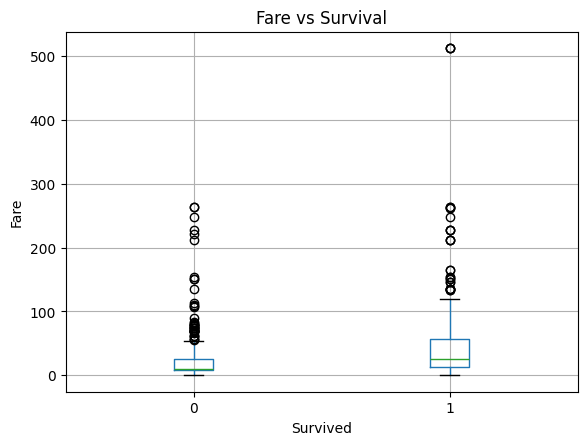

In [10]:
print(df.groupby('Survived')['Fare'].mean())

df.boxplot(column='Fare', by='Survived')
plt.title('Fare vs Survival')
plt.suptitle('')
plt.ylabel('Fare')
plt.show()

## Step 11: Embarkation Port Analysis
**Explanation:** Check if port of boarding affected survival.

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


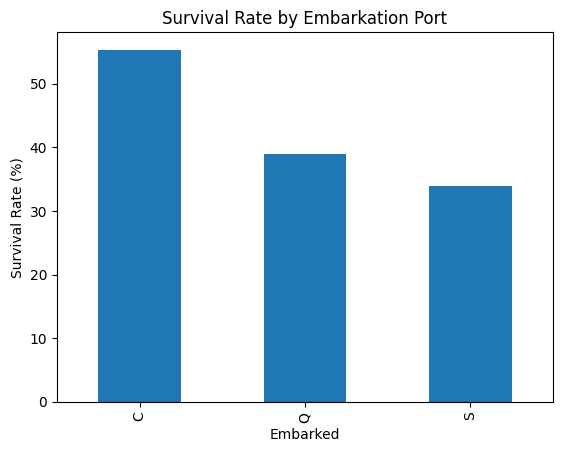

In [11]:
survival_by_port = df.groupby('Embarked')['Survived'].mean() * 100
print(survival_by_port)

survival_by_port.plot(kind='bar')
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate (%)')
plt.show()

## Step 12: Cabin Availability Impact
**Explanation:** Compare survival of passengers with cabin info vs those without.

In [12]:
survival_by_cabin = df.groupby('Has_Cabin')['Survived'].mean() * 100
print(survival_by_cabin)

Has_Cabin
0    29.985444
1    66.666667
Name: Survived, dtype: float64


## Step 13: Key Insights
**Explanation:** Summarize patterns and findings.

- Females had significantly higher survival rates.
- First-class passengers survived more.
- Higher fare passengers had better survival probability.
- Cabin availability slightly improved survival.
- Children survived at higher rates than adults.